In [7]:
import pandas as pd
import numpy as np

In [48]:
import pandas as pd
import numpy as np
df=pd.read_csv('D:\\csv files\\Non_linear_SVM_Dataset.csv')

In [15]:
df.head()

,X1,X2,Y
0,0.830858,-0.334342,1.0
1,0.991710,0.879000,0.0
2,1.107245,-0.470344,1.0
3,-0.140899,1.033148,0.0
4,0.405592,1.328529,0.0


In [49]:
Y=df["Y"]
X=df.iloc[:,0:2]
X.head()

,X1,X2
0,0.830858,-0.334342
1,0.991710,0.879000
2,1.107245,-0.470344
3,-0.140899,1.033148
4,0.405592,1.328529


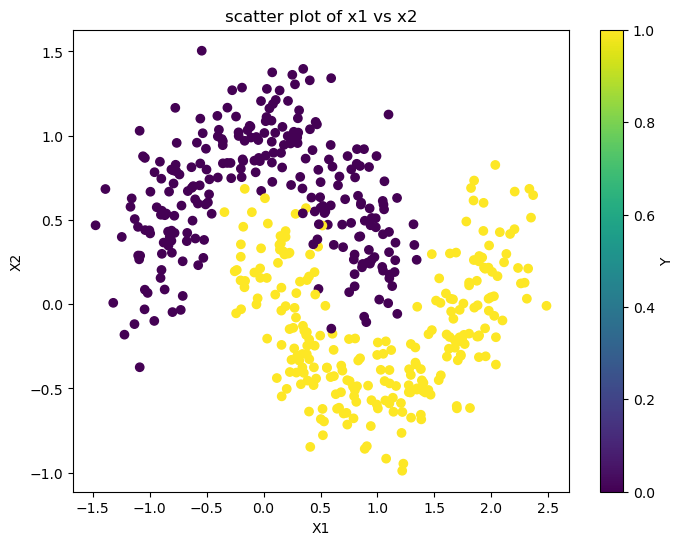

In [50]:
#x1 and x2 with plot in 2d
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=Y, cmap="viridis")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("scatter plot of x1 vs x2")
plt.colorbar(label="Y")
plt.show()


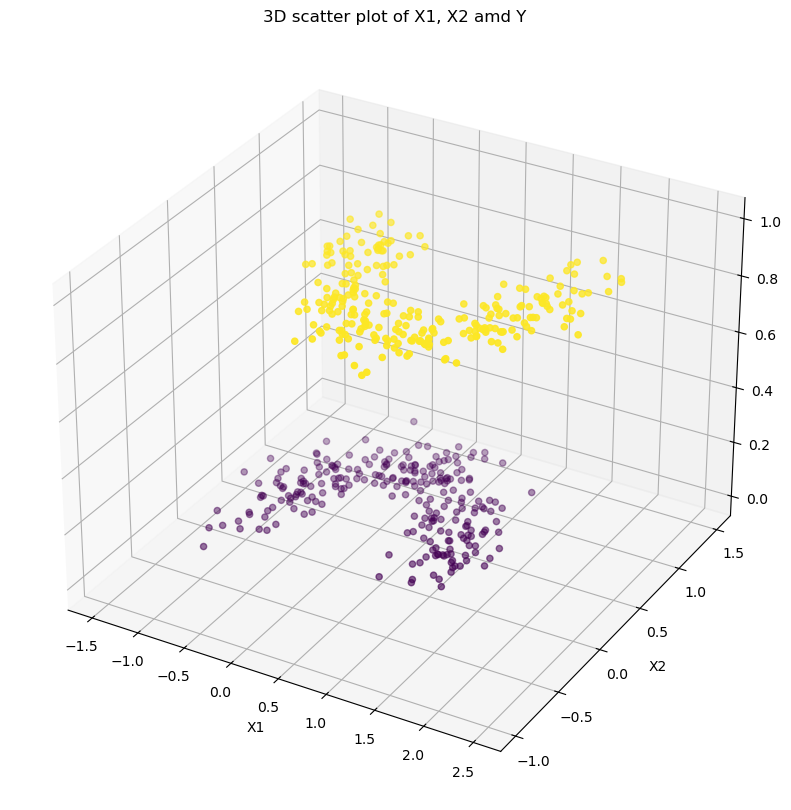

In [60]:
# x1 and x2 with 3d visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(X["X1"],X["X2"],Y, c=Y, cmap="viridis")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.set_title("3D scatter plot of X1, X2 amd Y")
plt.show()



In [62]:
# SVC using linear kernal method 
#accuracy score checking for X1 and X2
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3)
from sklearn.svm import SVC
model=SVC(kernel='linear')
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
score1=accuracy_score(y_train,y_pred_train)
score2=accuracy_score(y_test,y_pred_test)
print("Training Score:", np.round(score1,2))
print("Testing score:", np.round(score2,2)) 

Training Score: 0.85
Testing score: 0.87


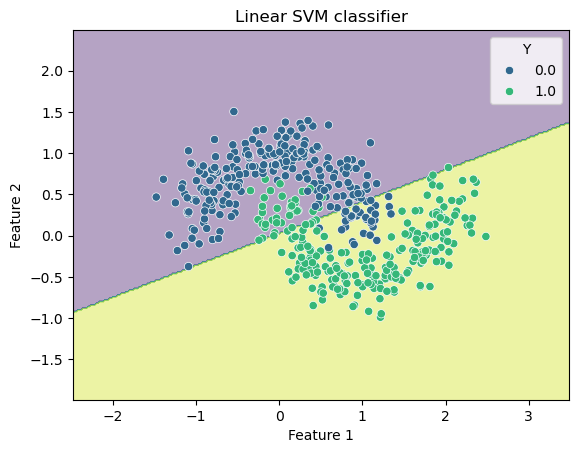

In [63]:
#svm using linear kernel 2d ploting
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap
x_min, x_max=X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1
y_min, y_max=X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1

xx,yy=np.meshgrid(np.arange(x_min, x_max, 0.02),
                  np.arange(y_min, y_max, 0.02))

Z=model.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx,yy,Z, alpha=0.4)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=Y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM classifier")
plt.show()

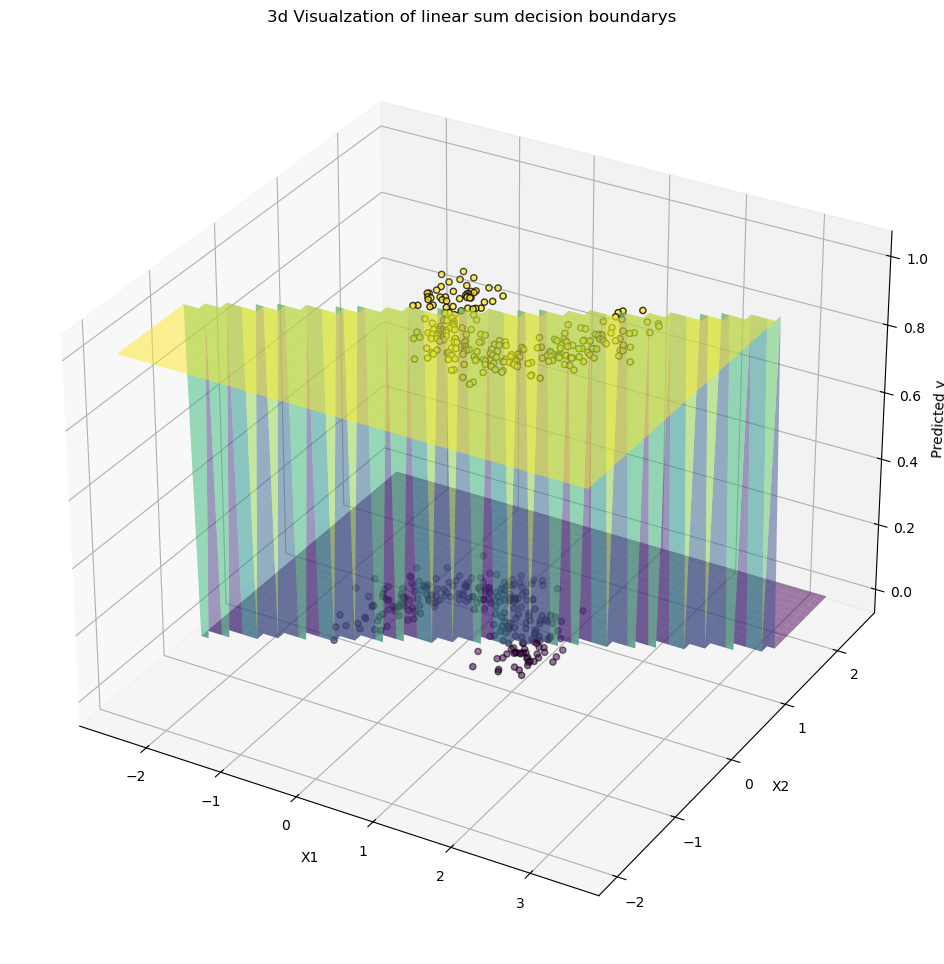

In [64]:
#svm using linear kernel 3d ploting
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
x_min,x_max=X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1
y_min,y_max=X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max, 0.1),
                  np.arange(y_min,y_max, 0.1))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
fig=plt.figure(figsize=(14,12))
ax=fig.add_subplot(111, projection='3d')
ax.plot_surface(xx,yy,Z, cmap='viridis', alpha=0.5)
ax.scatter(X['X1'], X['X2'], Y, c=Y, cmap='viridis', edgecolors='k')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Predicted y')
ax.set_title('3d Visualzation of linear sum decision boundarys')
plt.show()
                  

In [65]:
#polynomial classifier
from sklearn.svm import SVC
model=SVC(kernel='poly', degree=3)
model.fit(x_train,y_train)
Y_pred_train=model.predict(x_train)
Y_pred_test=model.predict(x_test)
from sklearn.metrics import accuracy_score
score1=accuracy_score(y_train,Y_pred_train)
score2=accuracy_score(y_test,Y_pred_test)
print("Training Score is:",np.round(score1,2))
print("Test score is:", np.round(score2,2))

Training Score is: 0.9
Test score is: 0.91


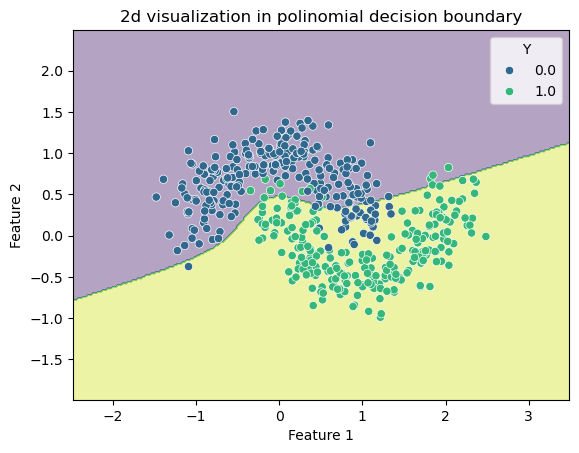

In [70]:
# visulization in 2d
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
x_min,x_max=X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1
y_min, y_max= X.iloc[:, 1].min()-1, X.iloc[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),
                  np.arange(y_min,y_max,0.02))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx,yy,Z,alpha=0.4)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1],hue=Y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("2d visualization in polinomial decision boundary")
plt.show()

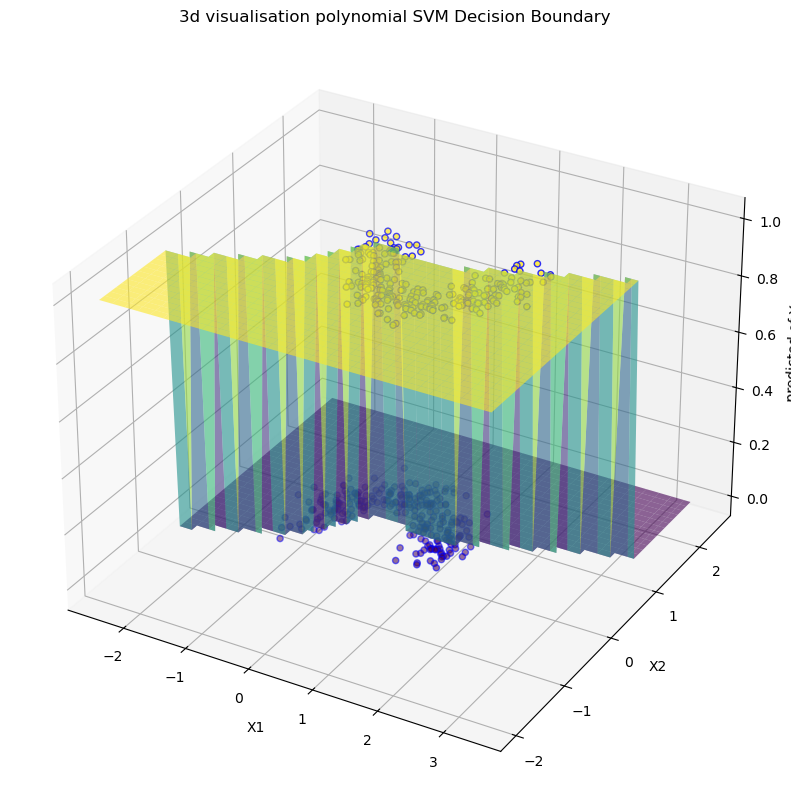

In [80]:
x_min,x_max=X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1
y_min,y_max=X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1
xx, yy=np.meshgrid(np.arange(x_min,x_max,0.1),
                   np.arange(y_min, y_max,0.1))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
fig=plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')
ax.plot_surface(xx,yy,Z, cmap='viridis', alpha=0.6)
ax.scatter(X['X1'],X['X2'],Y, c=Y, cmap='viridis', edgecolor='b')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('predicted of Y')
ax.set_title('3d visualisation polynomial SVM Decision Boundary')
plt.show()

In [82]:
#RBF (Radial Bias function) 
from sklearn.svm import SVC
model=SVC(kernel='rbf')
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
from sklearn.metrics import accuracy_score
acc_score1=accuracy_score(y_train,y_pred_train)
acc_score2=accuracy_score(y_test,y_pred_test)
print("Accuracy Train Score1:", np.round(acc_score1,2))
print("Accuracy test Score:", np.round(acc_score2,2))

Accuracy Train Score1: 0.97
Accuracy test Score: 0.99


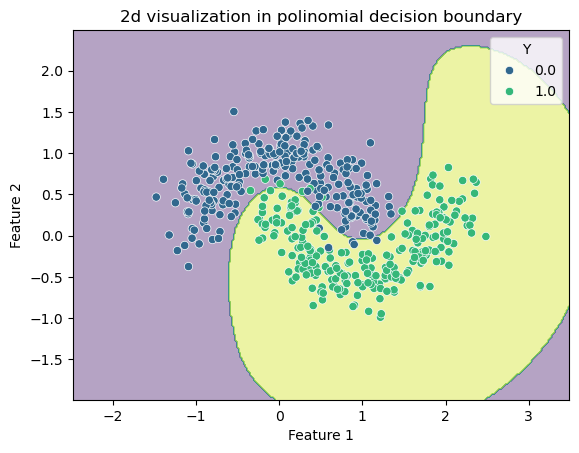

In [84]:
#RBF 2d Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
x_min,x_max=X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1
y_min, y_max= X.iloc[:, 1].min()-1, X.iloc[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),
                  np.arange(y_min,y_max,0.02))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx,yy,Z,alpha=0.4)
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1],hue=Y, palette="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("2d visualization in polinomial decision boundary")
plt.show()

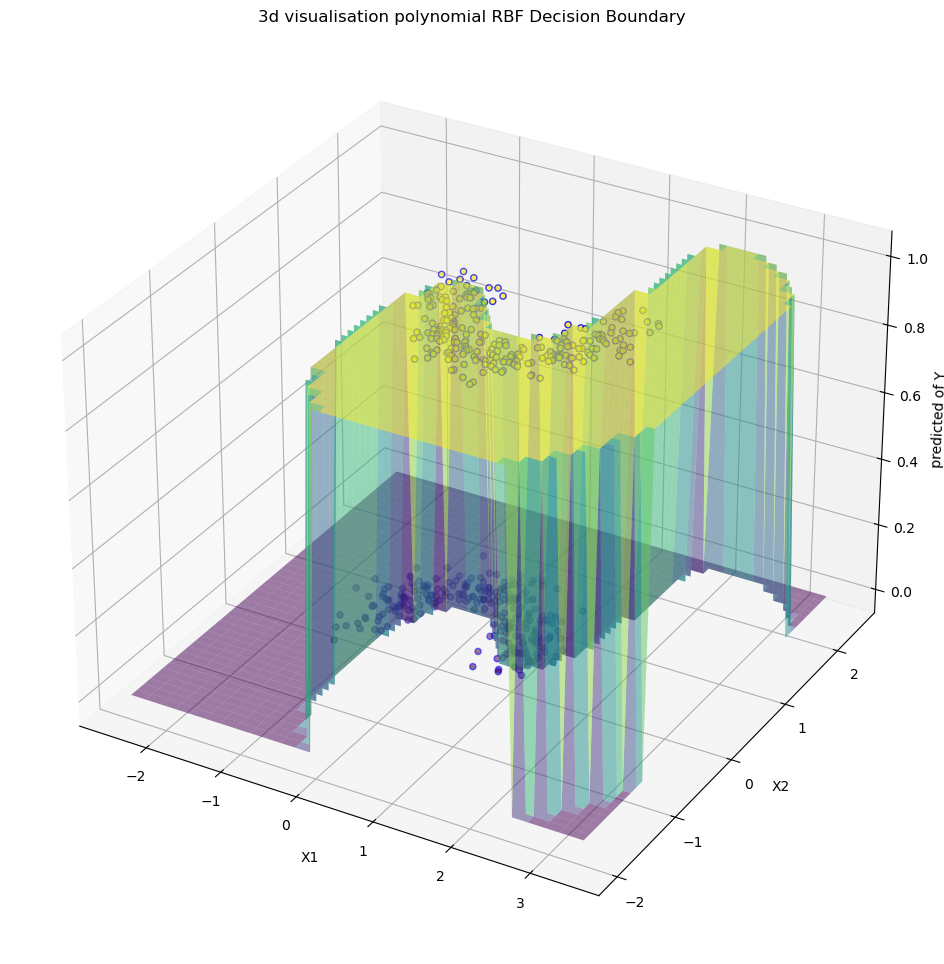

In [83]:
#RBF 3d Visualisation 
x_min,x_max=X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1
y_min,y_max=X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1
xx, yy=np.meshgrid(np.arange(x_min,x_max,0.1),
                   np.arange(y_min, y_max,0.1))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
fig=plt.figure(figsize=(14,12))
ax=fig.add_subplot(111, projection='3d')
ax.plot_surface(xx,yy,Z, cmap='viridis', alpha=0.5)
ax.scatter(X['X1'],X['X2'],Y, c=Y, cmap='viridis', edgecolor='b')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('predicted of Y')
ax.set_title('3d visualisation polynomial RBF Decision Boundary')
plt.show()

In [ ]:
#Sigmoid model 

In [3]:
# Four models in single program
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
df=pd.read_csv('D:\\csv files\\Pharma_Industry.csv')
X=df.iloc[:,0:3]
y=df["Drug Response"]
x_train,x_test, y_train,y_test=train_test_split(X,y,test_size=0.3,
                                                random_state=42)
models= {
    "linear" : SVC(kernel='linear',C=1.0),
    "polynomial" : SVC(kernel='poly',degree=3,C=1.0),
    "RBF" : SVC(kernel='rbf', gamma=0.5,C=1.0),
    "sigmoid" : SVC(kernel='sigmoid',gamma=0.5,C=1.0)
}
print("==== Model Accuracy====\n")
for name, model in models.items():
    model.fit(x_train,y_train)
    train_pred=model.predict(x_train)
    test_pred=model.predict(x_test)
    train_acc=accuracy_score(y_train,train_pred)
    test_acc=accuracy_score(y_test,test_pred)
    print(f"{name} SVM:")
    print(f"Training Accuracy:{train_acc:.2f}")
    print(f"testing Accuracy:{test_acc:.2f}")
    

==== Model Accuracy====

linear SVM:
Training Accuracy:0.62
testing Accuracy:0.59
polynomial SVM:
Training Accuracy:0.62
testing Accuracy:0.58
RBF SVM:
Training Accuracy:0.68
testing Accuracy:0.61
sigmoid SVM:
Training Accuracy:0.48
testing Accuracy:0.52
